# Area Between Two Curves

This code creates visualizations that show:

- **Plots two functions** (user input)
- **Visualizes the area between the curves** with rectangles
- **Computes the approximate area between curves** using numerical integration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Set up symbolic variable
x = sp.Symbol('x')

In [2]:
def area_between_curves(f_upper, f_lower, a, b, n):
    """
    Compute area between two curves using midpoint rule.
    
    Parameters:
    - f_upper: numpy function for upper curve
    - f_lower: numpy function for lower curve
    - a, b: integration bounds
    - n: number of rectangles
    """
    dx = (b - a) / n
    total = 0
    
    for i in range(n):
        x_sample = a + (i + 0.5) * dx  # midpoint
        height = f_upper(x_sample) - f_lower(x_sample)
        total += height * dx
    
    return total

def plot_area_between(f_expr_1, f_expr_2, a, b, n):
    """
    Plot two functions and visualize the area between them.
    
    Parameters:
    - f_expr_1, f_expr_2: sympy expressions for the two functions
    - a, b: integration bounds
    - n: number of rectangles
    """
    # Convert sympy expressions to numpy functions
    f1 = sp.lambdify(x, f_expr_1, 'numpy')
    f2 = sp.lambdify(x, f_expr_2, 'numpy')
    
    # Create fine x values for smooth curves
    x_vals = np.linspace(a, b, 500)
    y1_vals = f1(x_vals)
    y2_vals = f2(x_vals)
    
    # Calculate rectangle width
    dx = (b - a) / n
    
    # Plot the functions
    plt.figure(figsize=(12, 8))
    plt.plot(x_vals, y1_vals, color='blue', linewidth=2, label=f'f(x) = {f_expr_1}')
    plt.plot(x_vals, y2_vals, color='red', linewidth=2, label=f'g(x) = {f_expr_2}')
    
    # Fill the area between curves
    plt.fill_between(x_vals, y1_vals, y2_vals, alpha=0.2, color='green')
    
    # Draw rectangles and compute area
    area_approx = 0
    for i in range(n):
        x_sample = a + (i + 0.5) * dx  # midpoint
        x_left = a + i * dx
        
        y1 = f1(x_sample)
        y2 = f2(x_sample)
        
        # Determine which is upper and lower
        y_upper = max(y1, y2)
        y_lower = min(y1, y2)
        height = y_upper - y_lower
        
        area_approx += height * dx
        
        # Draw rectangle
        rect = plt.Rectangle((x_left, y_lower), dx, height, 
                            alpha=0.4, edgecolor='darkgreen', 
                            facecolor='yellow', linewidth=1.5)
        plt.gca().add_patch(rect)
        
        # Mark sample points
        plt.plot(x_sample, y1, 'bo', markersize=5)
        plt.plot(x_sample, y2, 'ro', markersize=5)
    
    # Compute exact area if possible
    try:
        # Area = integral of |f1 - f2|
        diff_expr = f_expr_1 - f_expr_2
        integral_expr = sp.integrate(diff_expr, (x, a, b))
        exact_value = abs(float(integral_expr.evalf()))
        error = abs(area_approx - exact_value)
        title = f'Area Between Two Curves with n={n} rectangles\n'
        title += f'Approximate Area: {area_approx:.6f}\n'
        title += f'Exact Area: {exact_value:.6f} | Error: {error:.6f}'
    except:
        title = f'Area Between Two Curves with n={n} rectangles\n'
        title += f'Approximate Area: {area_approx:.6f}'
    
    plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    plt.grid(True, alpha=0.3)
    plt.xlabel('x', fontsize=12)

    plt.ylabel('y', fontsize=12)    
    return area_approx

   # plt.title(title, fontsize=12)    

   # plt.legend(fontsize=10)    
   # plt.show()
   # plt.tight_layout()

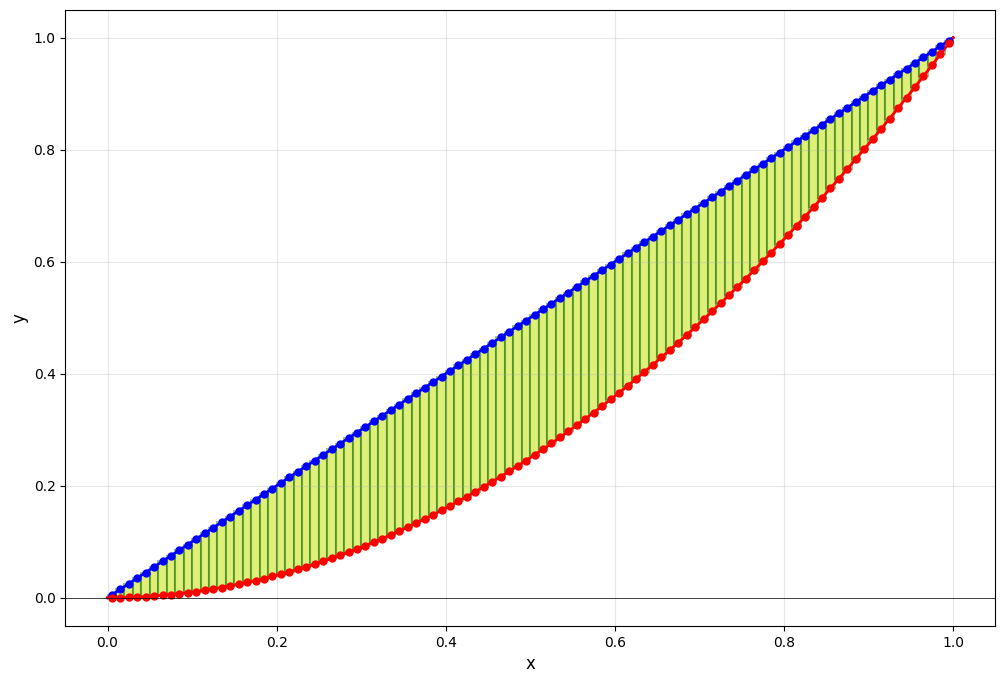

In [3]:
# Example 1: Area between a parabola and a line
# Curves: f(x) = x^2 and g(x) = x
a = 0
b = 1
# Upper and lower functions
f1 = x
f2 = x**2
# Number of rectangles
n = 100
# Compute and visualize the area between curves
area = plot_area_between(f1, f2, a, b, n)

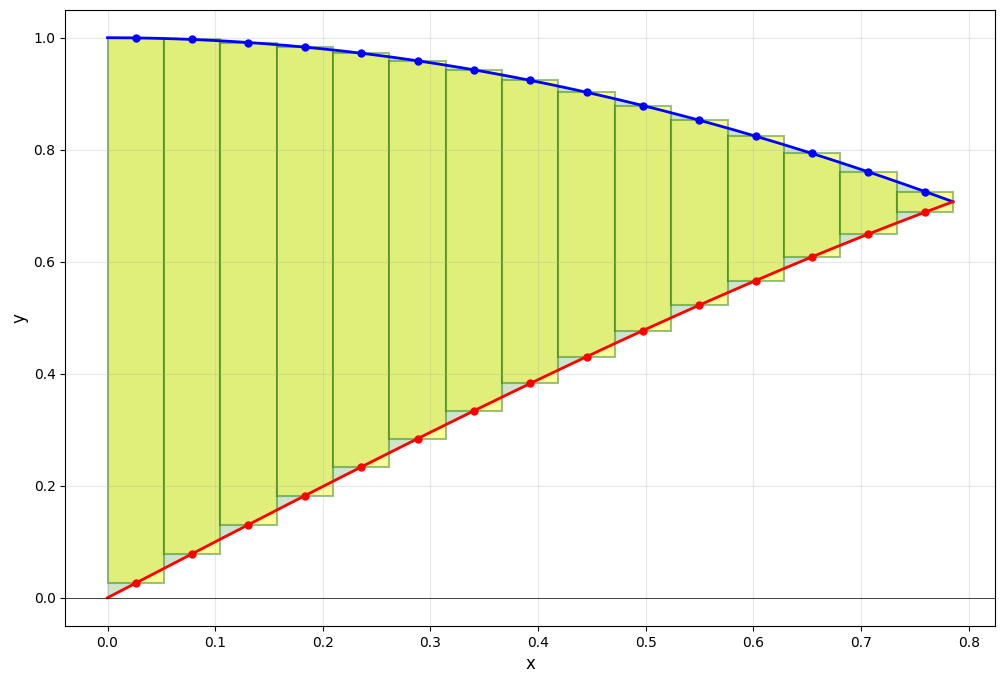

In [4]:
# Example 2: Area between sine and cosine
# Curves: f(x) = sin(x) and g(x) = cos(x)
a = 0
b = np.pi / 4
# Functions
f1 = sp.cos(x)
f2 = sp.sin(x)
# Number of rectangles
n = 15
# Compute and visualize the area between curves
area = plot_area_between(f1, f2, a, b, n)

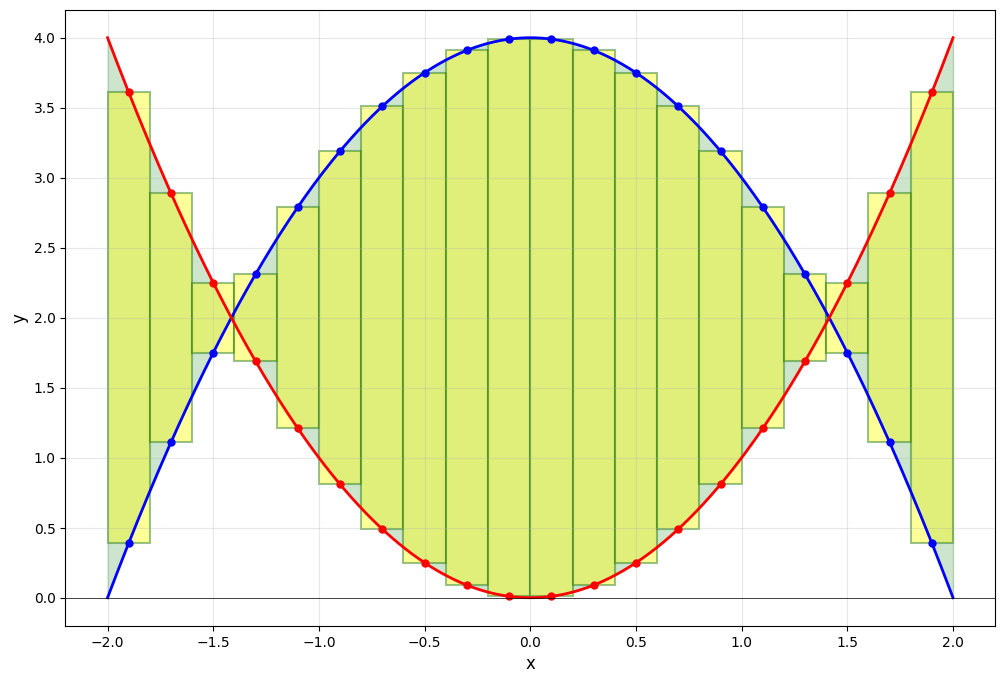

In [5]:
# Example 3: Area between parabolas
# Curves: f(x) = 4 - x^2 and g(x) = x^2
a = -2
b = 2
# Functions
f1 = 4 - x**2
f2 = x**2
# Number of rectangles
n = 20
# Compute and visualize the area between curves
area = plot_area_between(f1, f2, a, b, n)

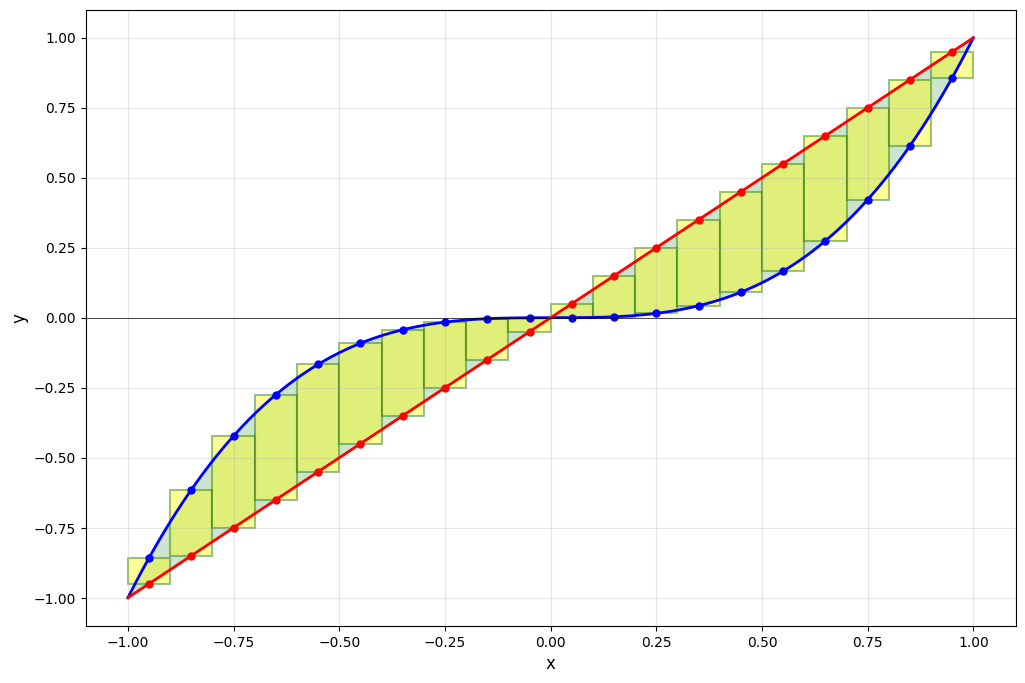

In [6]:
# Example 4: Area between cubic and line
# Curves: f(x) = x^3 and g(x) = x
a = -1
b = 1
# Functions
f1 = x**3
f2 = x
# Number of rectangles
n = 20
# Compute and visualize the area between curves
area = plot_area_between(f1, f2, a, b, n)


Area between e^x and x^2 + 1: 0.856617


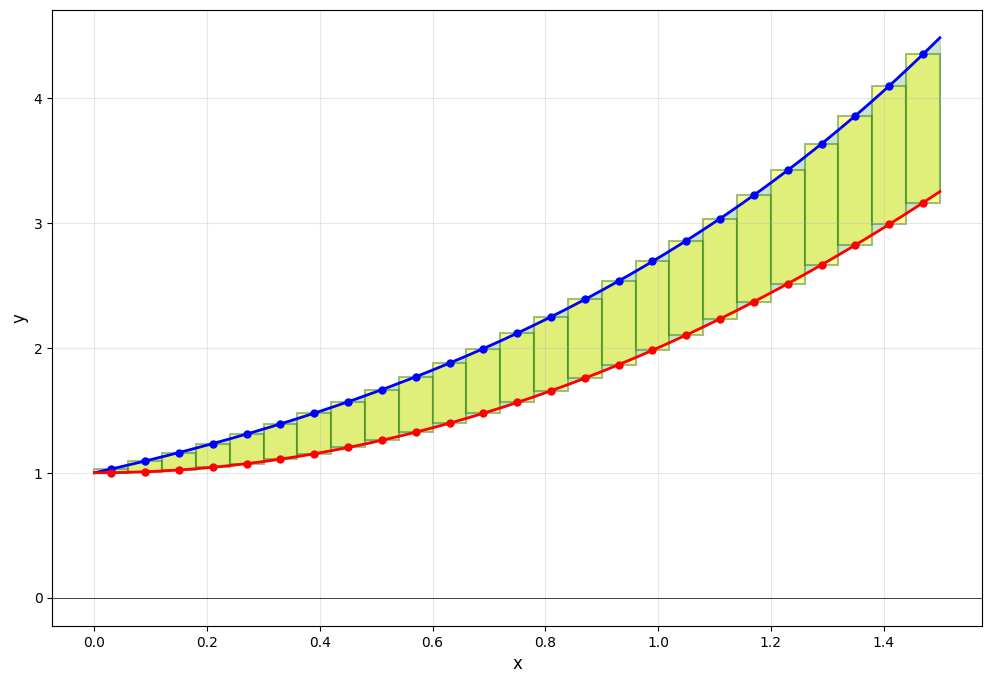

In [7]:
# Example 5: Area between exponential and quadratic
# Curves: f(x) = e^x and g(x) = x^2 + 1
a = 0
b = 1.5
# Functions
f1 = sp.exp(x)
f2 = x**2 + 1
# Number of rectangles
n = 25
# Compute and visualize the area between curves
area = plot_area_between(f1, f2, a, b, n)
print(f"\nArea between e^x and x^2 + 1: {area:.6f}")